In [33]:
# ===============================
# Imports & Config
# ===============================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


BASE_PATH = r"C:\Users\kaust\OneDrive\Documents\Honors\datasets"

TASK = "dual-user-inter"      
DOMAIN = "video_game"                 # change: m1, cloth_sport, etc

In [34]:
# ===============================
# Load Train / Test
# ===============================

base_dir = os.path.join(BASE_PATH, TASK, "dataset", DOMAIN)

train_path = os.path.join(base_dir, "train.txt")
test_path = os.path.join(base_dir, "test.txt")

print("Train:", train_path)
print("Test :", test_path)


train_df = pd.read_csv(train_path, sep="\t", header=None)
test_df = pd.read_csv(test_path, sep="\t", header=None)


print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_df.sample(5)

Train: C:\Users\kaust\OneDrive\Documents\Honors\datasets\dual-user-inter\dataset\video_game\train.txt
Test : C:\Users\kaust\OneDrive\Documents\Honors\datasets\dual-user-inter\dataset\video_game\test.txt
Train shape: (156091, 2)
Test shape : (1458, 2)


,0,1
26570,5083,1754
75111,10292,5807
109611,14073,170
51754,7695,65
88346,11757,1327


In [35]:
# ===============================
# Dataset Overview
# ===============================

n_users = train_df[0].nunique()
n_items = train_df[1].nunique()
n_inter = len(train_df)

print("Users       :", n_users)
print("Items       :", n_items)
print("Interactions:", n_inter)
# print("Columns     :", train_df.shape[1])

Users       : 19240
Items       : 8751
Interactions: 156091


In [36]:
# ===============================
# Sparsity
# ===============================

density = n_inter / (n_users * n_items)
sparsity = 1 - density

print("Density :", round(density, 6))
print("Sparsity:", round(sparsity, 6))

Density : 0.000927
Sparsity: 0.999073


Mean  : 8.11
Median: 6.0
Max   : 740


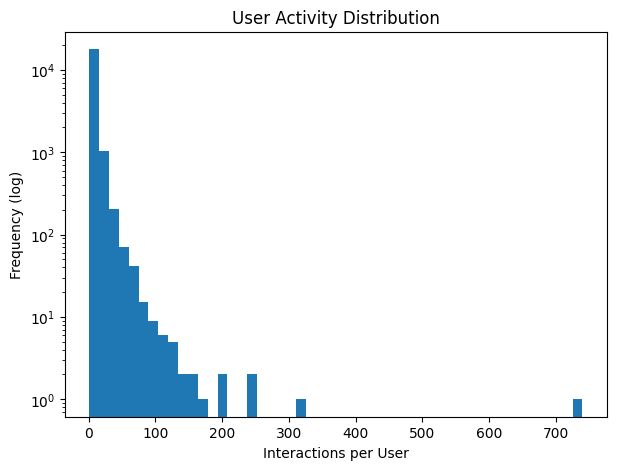

In [37]:
# ===============================
# User Activity
# ===============================

user_counts = train_df[0].value_counts()
# value counts means how many times a unique value appears (users) appears

# this is basically the avg number of interactions per user, but we also look at median and max to understand distribution
print("Mean  :", round(user_counts.mean(), 2))
print("Median:", user_counts.median())
print("Max   :", user_counts.max())

# histograms show many users with 0-10 interaction are present (the frequenchy)

plt.figure(figsize=(7,5))
user_counts.plot(kind="hist", bins=50, log=True)
plt.title("User Activity Distribution")
plt.xlabel("Interactions per User")
plt.ylabel("Frequency (log)")
plt.show()

Mean  : 17.84
Median: 10.0
Max   : 427


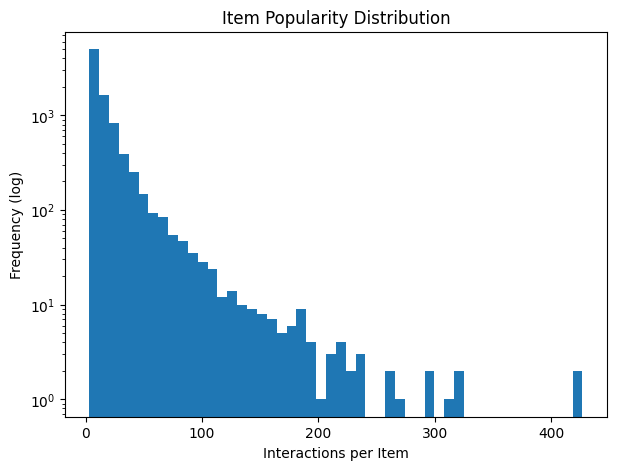

In [38]:
# ===============================
# Item Popularity
# ===============================

item_counts = train_df[1].value_counts()

print("Mean  :", round(item_counts.mean(), 2))
print("Median:", item_counts.median())
print("Max   :", item_counts.max())

# histograms show many items with 0-200 interaction are present (the frequency) --> frequency (log)


plt.figure(figsize=(7,5))
item_counts.plot(kind="hist", bins=50, log=True)
plt.title("Item Popularity Distribution")
plt.xlabel("Interactions per Item")
plt.ylabel("Frequency (log)")
plt.show()

In [39]:
# ===============================
# Cold Start
# ===============================

cold_users = (user_counts <= 2).sum()
cold_items = (item_counts <= 2).sum()

print("Cold Users (<=2):", cold_users)
print("Cold Items (<=2):", cold_items)

print("Cold User %:", round(cold_users / len(user_counts) * 100, 2))
print("Cold Item %:", round(cold_items / len(item_counts) * 100, 2))

Cold Users (<=2): 292
Cold Items (<=2): 0
Cold User %: 1.52
Cold Item %: 0.0


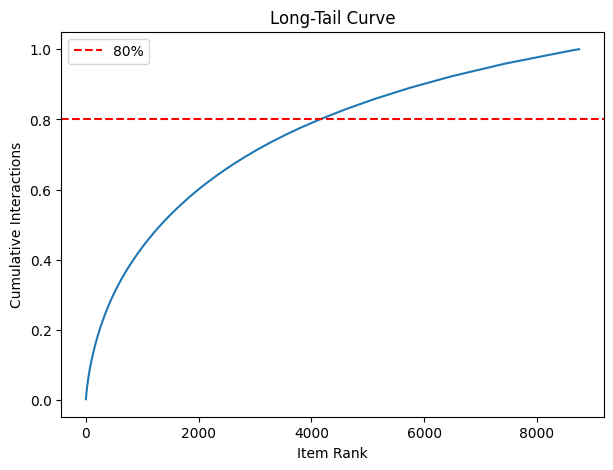

Items for 80% interactions: 4150
Total items: 8751


In [40]:
# ===============================
# Long Tail Analysis
# ===============================

# descending order of item popularity, popular ones at the start
sorted_pop = item_counts.sort_values(ascending=False)
cum = sorted_pop.cumsum() / sorted_pop.sum()



plt.figure(figsize=(7,5))
plt.plot(cum.values)
plt.axhline(0.8, color="red", linestyle="--", label="80%")
plt.title("Long-Tail Curve")
# more rank more popular
plt.xlabel("Item Rank")
plt.ylabel("Cumulative Interactions")
plt.legend()
plt.show()


top_80 = (cum <= 0.8).sum()


# 21% of items account for 80% of interactions, showing a moderate long-tail distribution in the dataset, where a small portion of items are very popular while many have low interactions.

# but it is still does not have high popularity bias

print("Items for 80% interactions:", top_80)
print("Total items:", len(sorted_pop))